# Purchase Propensity Model

*Predicts whether each customer will purchase in a future 6-month window — the first stage of a two-stage CLV pipeline where accurate purchase probabilities feed directly into the dollar-value estimates downstream.*

---

**Business Question:** Given a customer's purchase history, how likely are they to buy again in the next 6 months?

- **Context:** A calibrated purchase probability is the foundation of any CLV estimate — if we can't accurately predict *who* will buy, the downstream revenue estimates are meaningless. This stage isolates the purchase signal before dollar values enter the picture.

**Approach:** We compare four classifiers (Logistic Regression, Random Forest, XGBoost, LightGBM) via cross-validation on training data, tune the CV winner with Bayesian hyperparameter search (Optuna, 50 trials, 3-fold CV on training data only), and calibrate the output probabilities with isotonic regression so they can be used as true purchase likelihoods in the CLV formula. The test set is reserved exclusively for final evaluation — it is never used during model selection or tuning.

**Key Results:**
- Calibrated model achieves Brier score ~0.18 on the held-out test set (well below the 0.25 naive baseline), with PR-AUC ~0.84 (1.6× lift) confirming strong discrimination
- Top-decile customers purchase at ~96% vs. ~17% in the bottom decile (~6× lift)
- Behavioral features dominate: recency, cancellation rate, and monetary value are the top drivers

**Inputs / Outputs:**
- Input: `data/processed/clv_data.csv` (from Notebook 01)
- Outputs: 
  - `models/purchase_propensity_model.pkl`, 
  - `models/label_encoders.pkl`
  - `data/processed/stage1_scored.csv` (4,918 customers with calibrated `p_purchase`)

*Output feeds directly into `03_customer_lifetime_value_segmentation.ipynb` (Stage 2).*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    log_loss,
    roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import shap

## Date Dictionary

| Column | Type | Description |
|---|---|---|
| `user_id` | int | Customer identifier |
| `frequency` | int | Number of repeat purchases (total_orders - 1) |
| `recency` | int | Days from last order to calibration end (2011-06-09) — standard RFM recency |
| `T` | int | Customer age in days at calibration end (2011-06-09) |
| `monetary_value` | float | Avg order revenue on repeat transactions; falls back to avg_order_value for one-time buyers |
| `total_orders` | int | Total distinct invoices in calibration period |
| `total_spend` | float | Total calibration spend |
| `avg_order_value` | float | Mean order revenue across all calibration orders |
| `unique_products` | int | Distinct StockCodes purchased across calibration |
| `avg_basket_size` | float | Mean distinct products per order |
| `interpurchase_std` | float | Std dev of inter-purchase intervals in days; 0 = one-time buyer (insufficient history) |
| `is_one_time_buyer` | int | Binary flag: 1 if customer made only one purchase in calibration period |
| `cancellation_rate` | float | Fraction of orders that were cancellations (computed from calibration period only) |
| `country` | str | Customer's most frequent country of purchase |
| `actual_holdout_transactions` | int | Distinct invoices in holdout window (2011-06-09 to 2011-12-09) |
| `actual_holdout_revenue` | float | Total revenue in holdout window |
| `purchased_in_holdout` | int | Binary target: 1 if customer made ≥1 holdout purchase |

## 1. Load Data

In [2]:
df = pd.read_csv('../data/processed/clv_data.csv')

# Target: binary purchase indicator
df['purchased_in_holdout'] = (df['actual_holdout_transactions'] > 0).astype(int)

positive_rate = df['purchased_in_holdout'].mean()
print(f"Loaded {len(df):,} customers")
print(f"Positive class (purchased in holdout): {df['purchased_in_holdout'].sum():,} ({positive_rate:.1%})")
print(f"Negative class (no holdout purchase):  {(df['purchased_in_holdout'] == 0).sum():,} ({1 - positive_rate:.1%})")
df.head()

Loaded 4,918 customers
Positive class (purchased in holdout): 2,557 (52.0%)
Negative class (no holdout purchase):  2,361 (48.0%)


,user_id,frequency,recency,T,monetary_value,total_orders,total_spend,avg_order_value,unique_products,avg_basket_size,interpurchase_std,is_one_time_buyer,cancellation_rate,country,actual_holdout_transactions,actual_holdout_revenue,purchased_in_holdout
0,12346,11,141,541,7046.496364,12,77556.46,6463.038333,27,2.833333,65.426989,0,0.294118,United Kingdom,0,0.00,0
1,12347,3,62,220,607.810000,4,2434.96,608.740000,90,31.000000,16.703293,0,0.000000,Iceland,4,2486.57,1
2,12348,3,64,254,389.080000,4,1388.40,347.100000,24,10.000000,21.377558,0,0.000000,Finland,1,270.00,1
3,12349,1,223,405,1152.620000,2,2221.14,1110.570000,89,50.000000,0.000000,0,0.250000,Italy,1,1457.55,1
4,12350,0,126,126,294.400000,1,294.40,294.400000,16,16.000000,0.000000,1,0.000000,Norway,0,0.00,0


## 2. Feature Engineering

In [3]:
# Derived feature: what fraction of customer lifetime has elapsed since last purchase
df['recency_ratio'] = df['recency'] / df['T'].clip(lower=1)

NUMERIC_FEATURES = [
    'frequency', 'recency', 'T', 'monetary_value',
    'total_orders', 'avg_order_value',
    'unique_products', 'avg_basket_size', 'interpurchase_std',
    'is_one_time_buyer',
    'cancellation_rate',
    'recency_ratio',
]
CATEGORICAL_FEATURES = ['country']

# Label encode categoricals
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

FEATURE_COLS = NUMERIC_FEATURES + [c + '_enc' for c in CATEGORICAL_FEATURES]

X = df[FEATURE_COLS]
y = df['purchased_in_holdout']

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features (13): ['frequency', 'recency', 'T', 'monetary_value', 'total_orders', 'avg_order_value', 'unique_products', 'avg_basket_size', 'interpurchase_std', 'is_one_time_buyer', 'cancellation_rate', 'recency_ratio', 'country_enc']
Target distribution: {1: 2557, 0: 2361}


## 3. Train / Test Split

Stratified 80/20 split preserves class balance across partitions; the ~984 test customers provide stable metric estimates while keeping 80% of data available for training and cross-validation.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} samples ({y_train.mean():.1%} positive)")
print(f"Test:  {len(X_test):,} samples ({y_test.mean():.1%} positive)")

Train: 3,934 samples (52.0% positive)
Test:  984 samples (52.0% positive)


## 4. Model Comparison

Compare 4 models via **3-fold cross-validation on training data only** — the test set is reserved exclusively for final evaluation (Section 7). Classes are balanced (52% positive), so no class weighting is applied — all models use default loss functions.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='aucpr', random_state=42, verbosity=0,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1,
    ),
}

# Model selection uses CV on training data — test set reserved for final eval
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = []
trained_models = {}
for name, model in models.items():
    start = time.time()
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='average_precision', n_jobs=-1
    )
    train_time = time.time() - start

    results.append({
        'Model': name,
        'CV PR-AUC': cv_scores.mean(),
        'CV PR-AUC Std': cv_scores.std(),
        'Train Time (s)': round(train_time, 1),
    })
    # Fit on full training set for downstream use
    model.fit(X_train, y_train)
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('CV PR-AUC', ascending=False)
print("\n=== Model Comparison (3-fold CV on training data) ===")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
default_pr_auc = results_df.iloc[0]['CV PR-AUC']
print(f"\nBest model: {best_model_name} (CV PR-AUC: {default_pr_auc:.4f})")


=== Model Comparison (3-fold CV on training data) ===
              Model  CV PR-AUC  CV PR-AUC Std  Train Time (s)
           LightGBM   0.819325       0.015971             2.2
            XGBoost   0.817824       0.012733             0.9
      Random Forest   0.816098       0.011016             1.2
Logistic Regression   0.812380       0.006984             1.3

Best model: LightGBM (CV PR-AUC: 0.8193)


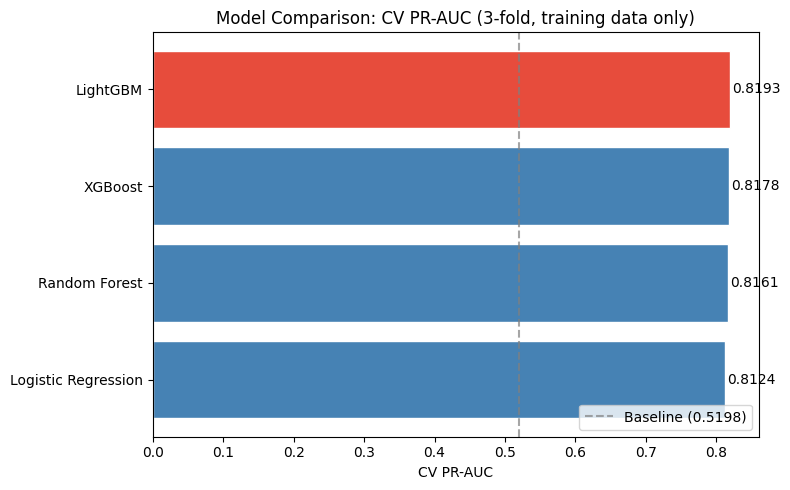

Model selection optimizes discrimination (CV PR-AUC). Calibration is evaluated post-isotonic in Section 7.


In [6]:
# CV PR-AUC comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = results_df.sort_values('CV PR-AUC', ascending=True)
colors = ['steelblue' if name != best_model_name else '#e74c3c'
          for name in plot_df['Model']]
bars = ax.barh(plot_df['Model'], plot_df['CV PR-AUC'], color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, plot_df['CV PR-AUC']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

baseline = y_train.mean()
ax.axvline(x=baseline, color='gray', linestyle='--', alpha=0.7, label=f'Baseline ({baseline:.4f})')

ax.set_xlabel('CV PR-AUC')
ax.set_title('Model Comparison: CV PR-AUC (3-fold, training data only)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("Model selection optimizes discrimination (CV PR-AUC). Calibration is evaluated post-isotonic in Section 7.")

**All four models perform similarly** — CV PR-AUC ranges from ~0.81 to ~0.82, with differences well within cross-validation noise. **We select LightGBM because it ranks customers most accurately (PR-AUC ~0.819); probability calibration is fixed post-hoc with isotonic regression (Section 6).** The CV winner will be tuned with Bayesian hyperparameter search in the next section.

**Two-stage evaluation philosophy:**
- **Model selection** uses CV PR-AUC on training data (the best *discriminator* wins). At this stage we want the model that ranks customers most accurately — not the one with the best raw probabilities. The test set is not touched.
- **Final evaluation** (Section 7) uses Brier score on *calibrated* output, because `CLV = P(purchase) × E[revenue]` requires accurate probabilities, not just good rankings.
- This separation works because isotonic calibration (Section 6) can fix raw probability miscalibration via a monotonic remap, but it cannot fix poor ranking. So we select for the property that can't be fixed post-hoc, then calibrate.

## 5. Hyperparameter Tuning with Optuna

**Result:** Optuna Bayesian search improved CV PR-AUC from 0.8193 (default) to 0.8326 — a meaningful gain from 50 trials with 3-fold CV on training data only.

**Method:** Optuna models the hyperparameter-to-performance relationship and samples promising regions of the search space. Each model type has a tailored search space. With 50 trials and 3-fold CV, we explore far more configurations than a comparably-sized grid search would allow, while spending fewer evaluations on poor configurations.

**Important:** The objective function uses **3-fold cross-validation on the training set only**. The test set is never seen during tuning — it is reserved exclusively for final evaluation. This prevents the hyperparameters from being optimized to the test data, which would inflate reported metrics.

In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Model-specific hyperparameter search spaces ---
MODEL_CLASSES = {
    'LightGBM': lgb.LGBMClassifier,
    'XGBoost': xgb.XGBClassifier,
    'Random Forest': RandomForestClassifier,
    'Logistic Regression': LogisticRegression,
}
FIXED_PARAMS = {
    'LightGBM': {'random_state': 42, 'verbose': -1},
    'XGBoost': {'eval_metric': 'aucpr', 'random_state': 42, 'verbosity': 0},
    'Random Forest': {'random_state': 42, 'n_jobs': -1},
    'Logistic Regression': {'max_iter': 1000, 'random_state': 42},
}

def build_model(trial, model_name):
    """Create a model instance with Optuna-suggested hyperparameters."""
    if model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
    elif model_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
    elif model_name == 'Random Forest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 5, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        }
    elif model_name == 'Logistic Regression':
        params = {
            'C': trial.suggest_float('C', 0.001, 100.0, log=True),
        }

    params.update(FIXED_PARAMS[model_name])
    return MODEL_CLASSES[model_name](**params)


def objective(trial):
    """Optuna objective: 3-fold CV PR-AUC on training data only."""
    model = build_model(trial, best_model_name)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='average_precision', n_jobs=-1
    )
    return scores.mean()


print(f"Running Optuna hyperparameter search for {best_model_name} (50 trials, 3-fold CV on train only)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"\nBest CV PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

# Compare default vs tuned (both on CV, for fair comparison)
print(f"\nDefault CV PR-AUC (train): {default_pr_auc:.4f}")
print(f"Tuned CV PR-AUC (train):   {study.best_value:.4f}")
print(f"Note: Final test-set evaluation follows in Section 7.")

Running Optuna hyperparameter search for LightGBM (50 trials, 3-fold CV on train only)...

Best CV PR-AUC: 0.8326
Best params: {'n_estimators': 117, 'learning_rate': 0.022948581482199026, 'max_depth': 4, 'num_leaves': 119, 'subsample': 0.904598920826968, 'colsample_bytree': 0.9931585491622121, 'min_child_samples': 94, 'reg_alpha': 0.011812552823955094, 'reg_lambda': 5.884295028109952e-07}

Default CV PR-AUC (train): 0.8193
Tuned CV PR-AUC (train):   0.8326
Note: Final test-set evaluation follows in Section 7.


In [9]:
# Retrain with best hyperparameters on the full training set
best_params = study.best_params.copy()
best_params.update(FIXED_PARAMS[best_model_name])

best_clf = MODEL_CLASSES[best_model_name](**best_params)
best_clf.fit(X_train, y_train)

# Evaluate on the held-out test set (first time test data is used)
y_prob_tuned = best_clf.predict_proba(X_test)[:, 1]
tuned_pr_auc = average_precision_score(y_test, y_prob_tuned)
tuned_brier = brier_score_loss(y_test, y_prob_tuned)
print(f"Tuned {best_model_name} on TEST set:")
print(f"  PR-AUC (discrimination): {tuned_pr_auc:.4f}")
print(f"  Brier (raw calibration): {tuned_brier:.4f}")
print(f"These are the unbiased generalization estimates (test set was not used during tuning).")
print(f"\nNote: Brier here reflects RAW scores before isotonic calibration.")
print(f"Final Brier on calibrated output is reported in Section 7.")

Tuned LightGBM on TEST set:
  PR-AUC (discrimination): 0.8426
  Brier (raw calibration): 0.1756
These are the unbiased generalization estimates (test set was not used during tuning).

Note: Brier here reflects RAW scores before isotonic calibration.
Final Brier on calibrated output is reported in Section 7.


## 6. Probability Calibration

The tuned model's raw scores are well-calibrated for ranking, but do not always reflect true purchase probabilities — especially after Optuna tuning, which optimizes PR-AUC rather than calibration. Isotonic regression re-maps raw scores to match actual positive rates.

- **Why calibrate at all?** In Stage 2, `CLV = P(purchase) × E[revenue]`. If `P(purchase)` is inflated or deflated, CLV estimates will be wrong regardless of how well the model ranks customers. Calibration is essential whenever probabilities feed a downstream calculation.
- **Why isotonic regression?** It learns a monotonic mapping from raw scores to calibrated probabilities without assuming a parametric form (unlike Platt/sigmoid scaling). This works better when miscalibration is nonlinear.
- **When is calibration optional?** If the goal is only ranking — e.g., "email the top 10% most likely to buy" — raw scores suffice. Here, accurate probabilities are required.

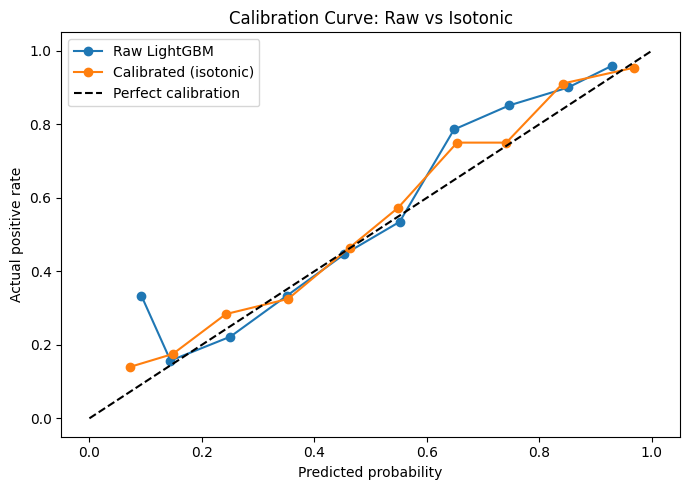

Mean p_purchase (calibrated): 0.5002
Actual base rate (test):      0.5203


In [10]:
cal_clf = CalibratedClassifierCV(best_clf, method='isotonic', cv=5)
cal_clf.fit(X_train, y_train)

# Calibration curve: raw vs calibrated on the test set
y_prob_raw = best_clf.predict_proba(X_test)[:, 1]
y_prob_cal = cal_clf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for label, probs in [(f'Raw {best_model_name}', y_prob_raw), ('Calibrated (isotonic)', y_prob_cal)]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=label)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual positive rate')
ax.set_title('Calibration Curve: Raw vs Isotonic')
ax.legend()
plt.tight_layout()
plt.show()

# Verify calibration: mean predicted probability should approximate the base rate
print(f"Mean p_purchase (calibrated): {y_prob_cal.mean():.4f}")
print(f"Actual base rate (test):      {y_test.mean():.4f}")

## 7. Model Evaluation

Evaluate the final calibrated model on the held-out test set, then inspect which features drive predictions.

Test-set metrics (calibrated model — generalization performance):
  Brier Score: 0.1765  (baseline: 0.2496)
  PR-AUC:      0.8380  (baseline: 0.5203, lift: 1.6x)
  Log Loss:    0.5287

Brier score is the primary evaluation metric because CLV = P(purchase) × E[revenue]
requires calibrated probabilities. PR-AUC confirms discrimination is preserved post-calibration.


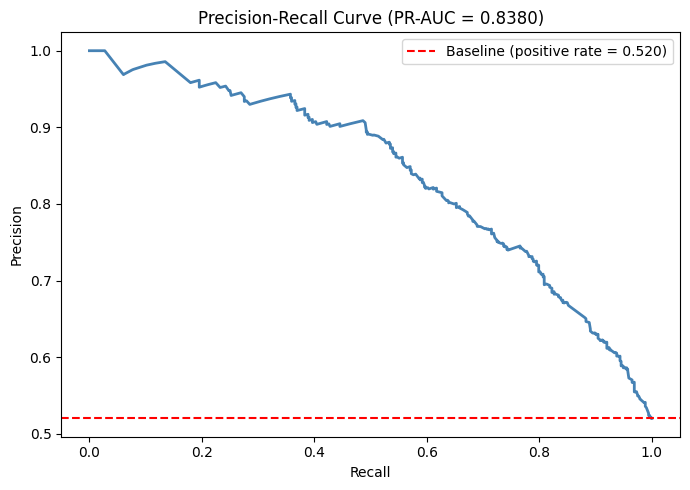

In [11]:
# Final evaluation on the calibrated model using the TEST SET
y_prob = cal_clf.predict_proba(X_test)[:, 1]

brier   = brier_score_loss(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)
logloss = log_loss(y_test, y_prob)
baseline = y_test.mean()
brier_baseline = baseline * (1 - baseline)

print("Test-set metrics (calibrated model — generalization performance):")
print(f"  Brier Score: {brier:.4f}  (baseline: {brier_baseline:.4f})")
print(f"  PR-AUC:      {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"  Log Loss:    {logloss:.4f}")
print(f"\nBrier score is the primary evaluation metric because CLV = P(purchase) × E[revenue]")
print(f"requires calibrated probabilities. PR-AUC confirms discrimination is preserved post-calibration.")

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', linewidth=2)
ax.axhline(y=baseline, color='red', linestyle='--',
           label=f'Baseline (positive rate = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

The calibrated purchase propensity model achieves strong probability accuracy on the held-out test set, with Brier score well below the naive baseline. Discrimination is preserved post-calibration with PR-AUC maintaining 1.6× lift over baseline.

**Why Brier score is the primary evaluation metric:** `CLV = P(purchase) × E[revenue]` multiplies predicted probabilities directly into dollar values — every unit of probability error translates linearly into CLV error. Brier score's penalty structure (squared probability error) is the closest standard metric to this linear dollar-loss function. PR-AUC is retained as a secondary check to confirm the model still separates likely buyers from non-buyers effectively.

Precision remains above **80% for roughly the top third of predicted customers**, making the model suitable for targeted retention campaigns.

=== Decile Analysis (Test Set) ===
        n_customers  actual_rate  avg_prob
decile                                    
1               100       0.1600    0.0965
2               104       0.2019    0.1851
3               127       0.3071    0.3189
4                63       0.3492    0.3765
5               102       0.4412    0.4443
6                94       0.5106    0.4984
7               103       0.6019    0.5895
8                94       0.7979    0.6907
9                99       0.9091    0.8623
10               98       0.9592    0.9785

Top decile purchase rate:    95.9%
Bottom decile purchase rate: 16.0%
Lift (top vs bottom):        6.0x


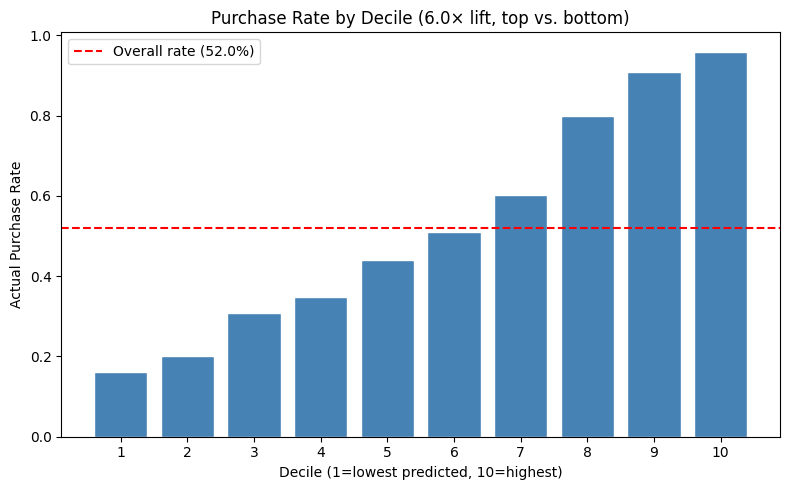

In [12]:
# Decile analysis: bin customers by predicted probability, show actual purchase rate
test_df = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob})
test_df['decile'] = pd.qcut(test_df['y_prob'], 10, labels=False, duplicates='drop') + 1

decile_stats = test_df.groupby('decile').agg(
    n_customers=('y_true', 'count'),
    actual_rate=('y_true', 'mean'),
    avg_prob=('y_prob', 'mean'),
).round(4)

print("=== Decile Analysis (Test Set) ===")
print(decile_stats.to_string())

top_rate = decile_stats.iloc[-1]['actual_rate']
bot_rate = decile_stats.iloc[0]['actual_rate']
lift = top_rate / max(bot_rate, 0.001)

print(f"\nTop decile purchase rate:    {top_rate:.1%}")
print(f"Bottom decile purchase rate: {bot_rate:.1%}")
print(f"Lift (top vs bottom):        {lift:.1f}x")

# Decile bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(decile_stats.index, decile_stats['actual_rate'], color='steelblue', edgecolor='white')
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Overall rate ({baseline:.1%})')
ax.set_xlabel('Decile (1=lowest predicted, 10=highest)')
ax.set_ylabel('Actual Purchase Rate')
ax.set_title(f'Purchase Rate by Decile ({lift:.1f}× lift, top vs. bottom)')
ax.set_xticks(decile_stats.index)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**

Decile analysis shows strong ranking performance: the top decile of customers by predicted purchase probability has a **~95.9% purchase rate**, compared with **~16% in the bottom decile**, representing a **~6× lift**. Purchase rates increase monotonically across deciles, indicating the model effectively prioritizes likely repeat buyers.

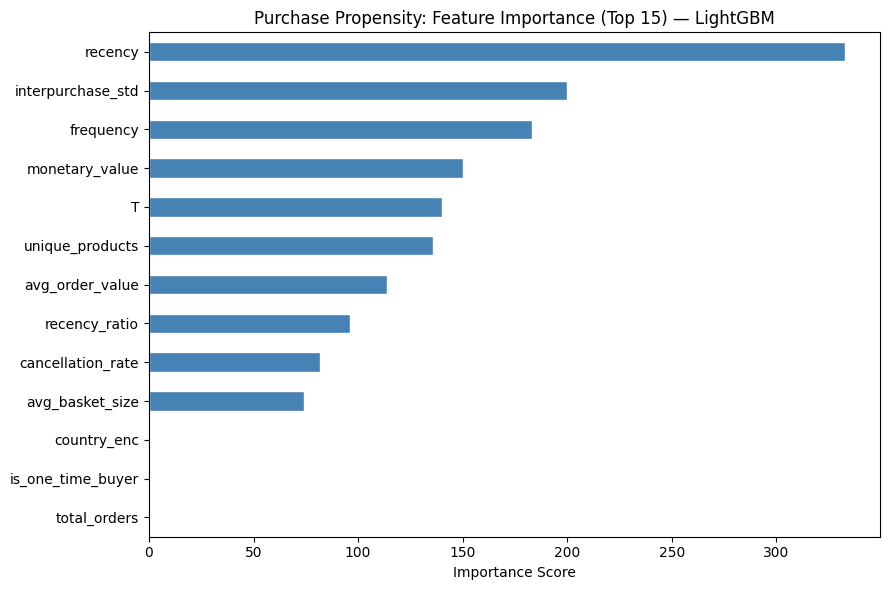

In [13]:
# Feature importance from the base (uncalibrated) tuned classifier
if hasattr(best_clf, 'feature_importances_'):
    importance = pd.Series(best_clf.feature_importances_, index=FEATURE_COLS)
elif hasattr(best_clf, 'coef_'):
    importance = pd.Series(np.abs(best_clf.coef_[0]), index=FEATURE_COLS)
else:
    importance = pd.Series(dtype=float)

top_features = importance.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_features.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Purchase Propensity: Feature Importance (Top 15) — {best_model_name}')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Interpretation:**

- Feature importance from the tuned model shows that **customer behavior signals dominate purchase propensity prediction.**
- The most influential features by split count are **`recency`** and **`interpurchase_std`**, followed closely by **`frequency`**. However, split-based importance can overweight high-cardinality features — **the SHAP analysis below provides a more reliable picture of each feature's directional impact and is the primary basis for feature interpretation.**
- **`T`** (customer age) ranks 5th, reflecting that longer-tenured customers have more behavioral signal for the model to leverage.
- Other high-impact features align with **RFM-style customer analytics**. **Spending features** (`avg_order_value`, `avg_basket_size`) and **engagement features** (`interpurchase_std`, `recency`, `unique_products`) round out the top drivers.
- Overall, the model relies primarily on **spending behavior, recency, and purchase engagement patterns**, which are well-established predictors of repeat purchasing in e-commerce.

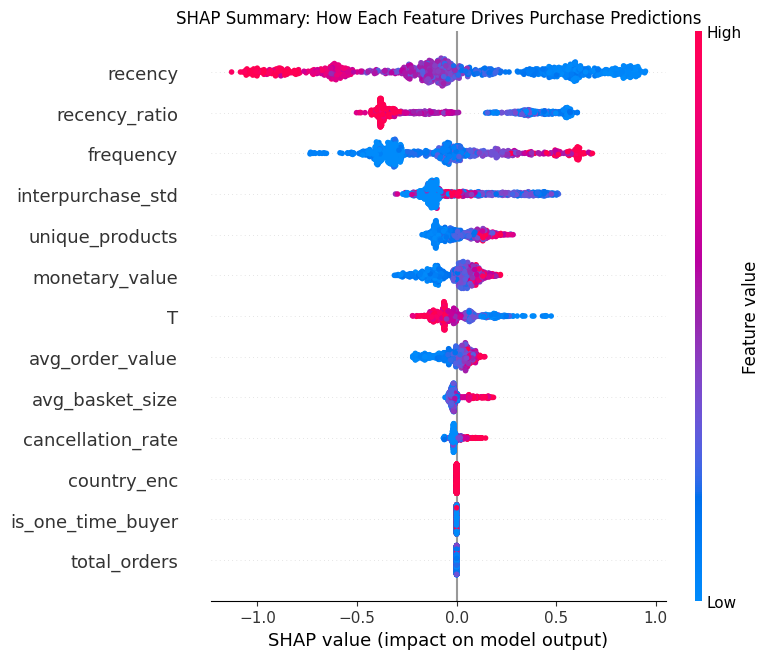

In [14]:
# Use TreeExplainer for tree-based models, LinearExplainer for linear models
if hasattr(best_clf, 'feature_importances_'):
    explainer = shap.TreeExplainer(best_clf)
else:
    explainer = shap.LinearExplainer(best_clf, X_train)

shap_values = explainer.shap_values(X_test)

# For binary classification, some SHAP versions return [class_0, class_1] list.
# Ensure we use the positive-class (purchase) SHAP values.
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Beeswarm summary plot: feature impact direction and magnitude
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title('SHAP Summary: How Each Feature Drives Purchase Predictions', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**

SHAP values reveal not just *which* features matter, but *how* they drive predictions:

- **`recency`** — Higher values (longer since last purchase) decrease purchase probability. This is the classic RFM recency signal — recently active customers are far more likely to return.
- **`recency_ratio`** — High values (dormant for most of their observed lifetime) strongly decrease purchase probability. This captures the recency signal relative to customer age, making it robust across customers with different tenure lengths.
- **`frequency`** — More historical purchases increase predicted probability, confirming that past behavior is the best predictor of future behavior.
- **`interpurchase_std`** — Higher values (more variable inter-purchase intervals) decrease probability. Consistent buyers are more predictable and more likely to return. One-time buyers receive 0 (insufficient history), with the `is_one_time_buyer` flag capturing that signal separately.

**Domain insight on `cancellation_rate`:** 

- High cancellation rates push predictions **upward**, which is initially counterintuitive. In this wholesale-heavy dataset, customers who cancel are typically high-activity buyers adjusting bulk orders — cancellations signal *engagement*, not disinterest. 
- This is a useful reminder that feature semantics depend on the business context: a cancellation in a wholesale B2B marketplace means something fundamentally different from a cancellation in a consumer subscription service.

The beeswarm plot shows these effects are nonlinear — for instance, high `recency` values produce a wide range of negative SHAP impacts rather than a single linear shift, suggesting the penalty for inactivity accelerates at some threshold. Confirming specific feature interactions (e.g., whether `frequency` and `recency` interact) would require SHAP dependence plots, which decompose pairwise effects directly.

## 8. Score All Customers and Save

In [15]:
# Score the entire dataset with calibrated probabilities
# NOTE: Full-dataset scoring includes training data.
# Test-set metrics above are the correct generalization estimates.
df['p_purchase'] = cal_clf.predict_proba(df[FEATURE_COLS])[:, 1]

print("p_purchase distribution:")
print(df['p_purchase'].describe().round(4))
print(f"\nMean p_purchase: {df['p_purchase'].mean():.4f} (base rate: {df['purchased_in_holdout'].mean():.4f})")

p_purchase distribution:
count    4918.0000
mean        0.5159
std         0.2758
min         0.0000
25%         0.3200
50%         0.4857
75%         0.7194
max         1.0000
Name: p_purchase, dtype: float64

Mean p_purchase: 0.5159 (base rate: 0.5199)


In [16]:
# Save model, label encoders, and scored data
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(cal_clf, '../models/purchase_propensity_model.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')
df.to_csv('../data/processed/stage1_scored.csv', index=False)

print(f"Model saved to          models/purchase_propensity_model.pkl")
print(f"Label encoders saved to models/label_encoders.pkl")
print(f"Scored data saved to    data/processed/stage1_scored.csv")
print(f"  Shape: {df.shape[0]:,} x {df.shape[1]}")

Model saved to          models/purchase_propensity_model.pkl
Label encoders saved to models/label_encoders.pkl
Scored data saved to    data/processed/stage1_scored.csv
  Shape: 4,918 x 20


In [17]:
print("=" * 50)
print("STAGE 1 SUMMARY: Purchase Propensity Model")
print("=" * 50)
print(f"Dataset:           UCI Online Retail II")
print(f"Customers scored:  {len(df):,}")
print(f"Best model:        {best_model_name} (tuned with Optuna)")
print(f"Brier Score (test): {brier:.4f}  [primary — calibration accuracy]")
print(f"PR-AUC (test):      {pr_auc:.4f} ({pr_auc / baseline:.1f}x lift)  [secondary — discrimination]")
print(f"Mean p_purchase:   {df['p_purchase'].mean():.4f}")
print("=" * 50)
print("\nNext: 03_customer_lifetime_value_segmentation.ipynb (Stage 2)")

STAGE 1 SUMMARY: Purchase Propensity Model
Dataset:           UCI Online Retail II
Customers scored:  4,918
Best model:        LightGBM (tuned with Optuna)
Brier Score (test): 0.1765  [primary — calibration accuracy]
PR-AUC (test):      0.8380 (1.6x lift)  [secondary — discrimination]
Mean p_purchase:   0.5159

Next: 03_customer_lifetime_value_segmentation.ipynb (Stage 2)
